In [1]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
print(tf.__version__)

2.19.0


In [2]:
import matplotlib.pyplot as plt
import numpy as np


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import os
print(os.listdir('/content/drive/MyDrive'))
print("Num GPUs available:", len(tf.config.list_physical_devices('GPU')))

['behla excel.gsheet', 'Solar system.pptx', 'Solar system.pptx.gslides', 'abbas.docx', 'Marasiya Book.pdf', 'tolerating skit script.gdoc', 'Lafz Maana Fiqeh Year 9 .pdf', 'Year 9_Dirasat Islamiyyah Portions for the First Term Exams.pdf', 'IMG_0079.JPG', 'IMG_0068.JPG', 'IMG_0065.JPG', 'IMG_0063.JPG', 'IMG_0057.JPG', 'IMG_0036.JPG', 'image.jpg', 'IMG_0021.JPG', 'IMG_0055.JPG', 'Presentation2.pptx', 'fasle sani portion year 9B.pdf', 'Screenshot_2019-06-02-14-36-30-644_com.instagram.android.png', 'SAVE_20190601_160543.jpg', 'SAVE_20190601_160549.jpg', 'SAVE_20190601_160537.jpg', 'YEAR 9 Final Exam portion.pdf', 'timeline world war one.docx', 'https:  youtu.b.txt', 'Majmua_1436.pdf', 'Majmua_1437.pdf', 'Try Google Opinion Rewards', '5. Kalaam_Matami_ Noha Page 2.jpg', '4. Kalaam_Matami Noha_Page 1.jpg', 'amazon fire rough draft.docx', 'IMG_0017.JPG', '0417 IGCSE ICT Text book.pdf', 'Netflix_v7.33.1 MOD_apkmody.io', 'HIIII.gdoc', 'GA1 Colombia Civil War.gdoc', 'Committee: General Assembly 1

In [5]:
print(os.listdir('/content/drive/MyDrive/forest_fire_dataset/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET/test'))


['Smoke', 'fire', 'non fire']


In [ ]:
# helper function to check if images corrupted or not in dataset
from PIL import Image
import imghdr # To check image format

def find_corrupted_images(directory):
    corrupted_files = []
    print(f"Checking directory: {directory}")
    for root, _, files in os.walk(directory):
        for file in files:
            filepath = os.path.join(root, file)
            # Attempting to identify the image type first
            img_type = imghdr.what(filepath)
            if img_type is None and not file.lower().endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp', '.tiff')):
                # Skips if it's clearly not an image file type and imghdr can't identify it
                continue
            try:
                with Image.open(filepath) as img:
                    img.verify() # Verifies that it is an image

            except (IOError, SyntaxError, Image.UnidentifiedImageError) as e:
                print(f"Corrupted or unidentifiable file found: {filepath} - Error: {e}")
                corrupted_files.append(filepath)
    return corrupted_files


corrupted_train = find_corrupted_images(train_dir)
corrupted_test = find_corrupted_images(test_dir)

if not corrupted_train and not corrupted_test:
    print("No corrupted or unidentifiable image files found in the specified directories.")
else:
    print("\nSummary of corrupted/unidentifiable files:")
    for f in corrupted_train:
        print(f"  Training: {f}")
    for f in corrupted_test:
        print(f"  Testing: {f}")





In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (128, 128)  # we can adjust the size of img and batch as we want
batch_size = 32

train_dir = '/content/drive/MyDrive/forest_fire_dataset/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET/train'
test_dir = '/content/drive/MyDrive/forest_fire_dataset/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET/test'

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'

)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)
test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)




Found 32397 images belonging to 3 classes.
Found 10500 images belonging to 3 classes.


In [7]:
#Verify class indices mapping and images counts

print("Class indices mapping:", train_data.class_indices)
print("Total train samples:", train_data.samples)
print("Total test samples:", test_data.samples)
for class_name, idx in train_data.class_indices.items():
    count = len(os.listdir(os.path.join(train_dir, class_name)))
    print(f"Train class '{class_name}': {count}")
for class_name, idx in test_data.class_indices.items():
    count = len(os.listdir(os.path.join(test_dir, class_name)))
    print(f"Test class '{class_name}': {count}")

Class indices mapping: {'Smoke': 0, 'fire': 1, 'non fire': 2}
Total train samples: 32397
Total test samples: 10500
Train class 'Smoke': 10799
Train class 'fire': 10800
Train class 'non fire': 10800
Test class 'Smoke': 3500
Test class 'fire': 3500
Test class 'non fire': 3500


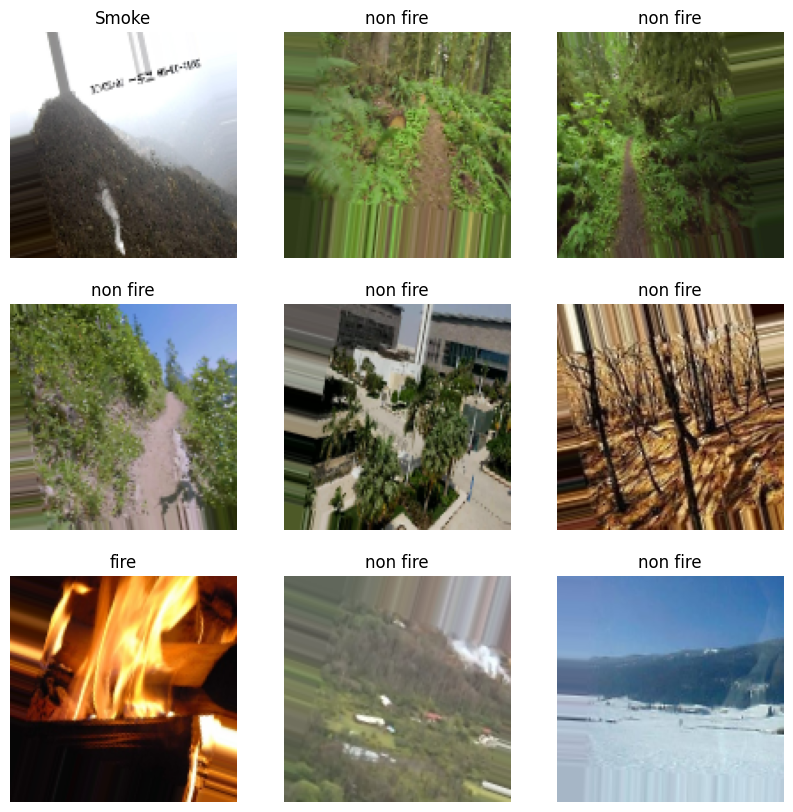

In [ ]:
#testing if the images are loaded properly or not


images, labels = next(train_data)  # Gets a batch of images and labels

class_names = list(train_data.class_indices.keys())  # ['Smoke', 'fire', 'non fire']

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis('off')
plt.show()


In [ ]:

# Builds a Sequential CNN model
from tensorflow.keras.layers import Dropout
model = tf.keras.models.Sequential([
    # First convolutional layer: learns 32 filters, each 3x3 in size
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    # Reduce size with MaxPooling (picks the brightest pixel in each 2x2 window)
    tf.keras.layers.MaxPooling2D(2, 2),

    # Second convolutional layer: learns 64 filters
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    # third layer: 128 filters
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    # Flatten 3D features to 1D (to connect to dense layers)
    tf.keras.layers.Flatten(),
    Dropout(0.5),  # Dropout to prevent memorization (overfitting)

    # Fully connected layer with 128 neurons
    tf.keras.layers.Dense(512, activation='relu'),
    Dropout(0.5),
    # Output layer: 3 units (fire, smoke, non fire) with softmax for probability
    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer= Adam(learning_rate=0.0001),          # popular, efficient optimizer
    loss='categorical_crossentropy',              # loss for multi-class problems
    metrics=['accuracy']                          # track accuracy during train/test
)
model.summary()   # Prints a table showing what each layer is and how many parameters are trained there

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,940,355 (49.36 MB)

 Trainable params: 12,940,355 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# Saves checkpoints after every epoch in case of interrupt
checkpoint_path = '/content/drive/MyDrive/model_checkpoints/cp-{epoch:02d}.weights.h5'

# Ensures the directory exists
checkpoint_dir = os.path.dirname(checkpoint_path)
if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)

cp_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    verbose=1,
    save_freq='epoch'
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [ ]:
import glob
import re

checkpoint_dir = '/content/drive/MyDrive/model_checkpoints'
checkpoint_files = glob.glob(os.path.join(checkpoint_dir, 'cp-*.weights.h5'))

def extract_epoch(filename):
    match = re.search(r'cp-(\d+)\.weights\.h5', filename)
    return int(match.group(1)) if match else -1

if checkpoint_files:
    latest_checkpoint = max(checkpoint_files, key=extract_epoch)
    print("Loading weights from:", latest_checkpoint)
    model.load_weights(latest_checkpoint)
else:
    print("No checkpoint found, starting from scratch.")


Loading weights from: /content/drive/MyDrive/model_checkpoints/cp-07.weights.h5


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
# Training the model
history = model.fit(
    train_data,              # the training data batches
    epochs=10,                # number of times our model will seetraining images
    callbacks=[cp_callback, early_stop]  # This saves progress after every epoch with early stop

)





/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.9481 - loss: 0.1564 
Epoch 1: saving model to /content/drive/MyDrive/model_checkpoints/cp-01.weights.h5
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 14767s 15s/step - accuracy: 0.9481 - loss: 0.1564
Epoch 2/10


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9488 - loss: 0.1506
Epoch 2: saving model to /content/drive/MyDrive/model_checkpoints/cp-02.weights.h5
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 1899s 2s/step - accuracy: 0.9488 - loss: 0.1506
Epoch 3/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9502 - loss: 0.1421
Epoch 3: saving model to /content/drive/MyDrive/model_checkpoints/cp-03.weights.h5
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 1902s 2s/step - accuracy: 0.9502 - loss: 0.1421
Epoch 4/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9524 - loss: 0.1418
Epoch 4: saving model to /content/drive/MyDrive/model_checkpoints/cp-04.weights.h5
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 1897s 2s/step - accuracy: 0.9524 - loss: 0.1418
Epoch 5/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9553 - loss: 0.1309
Epoch 5: saving model to /content/drive/MyDrive/model_checkpoints/cp-05.weights.h5
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 1894s 2s/step - accuracy: 0.9553 - loss: 0.1309
Epoch 6/10
1013

KeyboardInterrupt: 

In [ ]:
# Save the full model
model.save('/content/drive/MyDrive/my_forest_fire_model3.keras')


In [8]:
# Then load model
from tensorflow import keras
model = keras.models.load_model('/content/drive/MyDrive/my_forest_fire_model3.keras')
model.compile(
    optimizer= Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,940,355 (49.36 MB)

 Trainable params: 12,940,355 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Evaluate Accuracy and Loss
loss, accuracy = model.evaluate(test_data, verbose=1)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


329/329 ━━━━━━━━━━━━━━━━━━━━ 3323s 10s/step - accuracy: 0.9427 - loss: 0.1626
Test Loss: 0.12738579511642456
Test Accuracy: 0.9573333263397217


In [ ]:
#Predict All Test Samples
Y_pred = model.predict(test_data)
print("Prediction probabilities, first 10 samples:")
print(Y_pred[:10])
y_pred_classes = np.argmax(Y_pred, axis=1)
y_true = test_data.classes
class_labels = list(test_data.class_indices.keys())


329/329 ━━━━━━━━━━━━━━━━━━━━ 212s 642ms/step
Prediction probabilities, first 10 samples:
[[5.7487638e-04 2.8579435e-03 9.9656713e-01]
 [2.0969449e-02 1.6541999e-02 9.6248847e-01]
 [5.0776315e-01 2.8275415e-01 2.0948255e-01]
 [9.3442601e-01 7.6313531e-03 5.7942554e-02]
 [9.7707015e-01 5.7116272e-03 1.7218169e-02]
 [9.5167029e-01 8.2847546e-04 4.7501072e-02]
 [2.0311093e-02 8.6884895e-05 9.7960198e-01]
 [8.9832234e-01 8.6659156e-03 9.3011700e-02]
 [9.9814737e-01 5.3470609e-05 1.7992028e-03]
 [9.4274384e-01 5.1694013e-02 5.5622468e-03]]


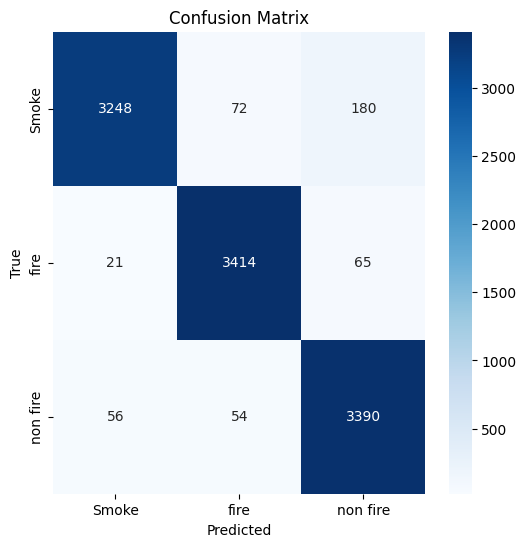


Classification Report:

              precision    recall  f1-score   support

       Smoke       0.98      0.93      0.95      3500
        fire       0.96      0.98      0.97      3500
    non fire       0.93      0.97      0.95      3500

    accuracy                           0.96     10500
   macro avg       0.96      0.96      0.96     10500
weighted avg       0.96      0.96      0.96     10500



In [ ]:
#Confusion Matrix & Classification Report
#Confusion Matrix: Shows how many images of each class were classified correctly vs. misclassified.
#Classification Report: Gives precision, recall, F1-score for each class

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
conf_mat = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6,6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

Plot 1: /content/drive/MyDrive/forest_fire_dataset/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET/test/fire/Fire (145).jpeg (T:fire, P:fire)
Plot 2: /content/drive/MyDrive/forest_fire_dataset/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET/test/Smoke/Smoke (239).jpg (T:Smoke, P:Smoke)
Plot 3: /content/drive/MyDrive/forest_fire_dataset/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET/test/non fire/NON_FIRE (4823).jpg (T:non fire, P:non fire)
Plot 4: /content/drive/MyDrive/forest_fire_dataset/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET/test/fire/Fire (100).png (T:fire, P:fire)
Plot 5: /content/drive/MyDrive/forest_fire_dataset/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET/test/non fire/NON_FIRE (5680).jpg (T:non fire, P:non fire)
Plot 6: /content/drive/MyDrive/forest_fire_dataset/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET/test/non fire/NF_1547.jpg (T:non fire, P:non fire)
Plot 7: /content/drive/MyDrive/forest_fire_dataset/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET/test/non fire/NON_FIRE (2218).jpg (T:non fire, P:non fire)
Plot 8: /co

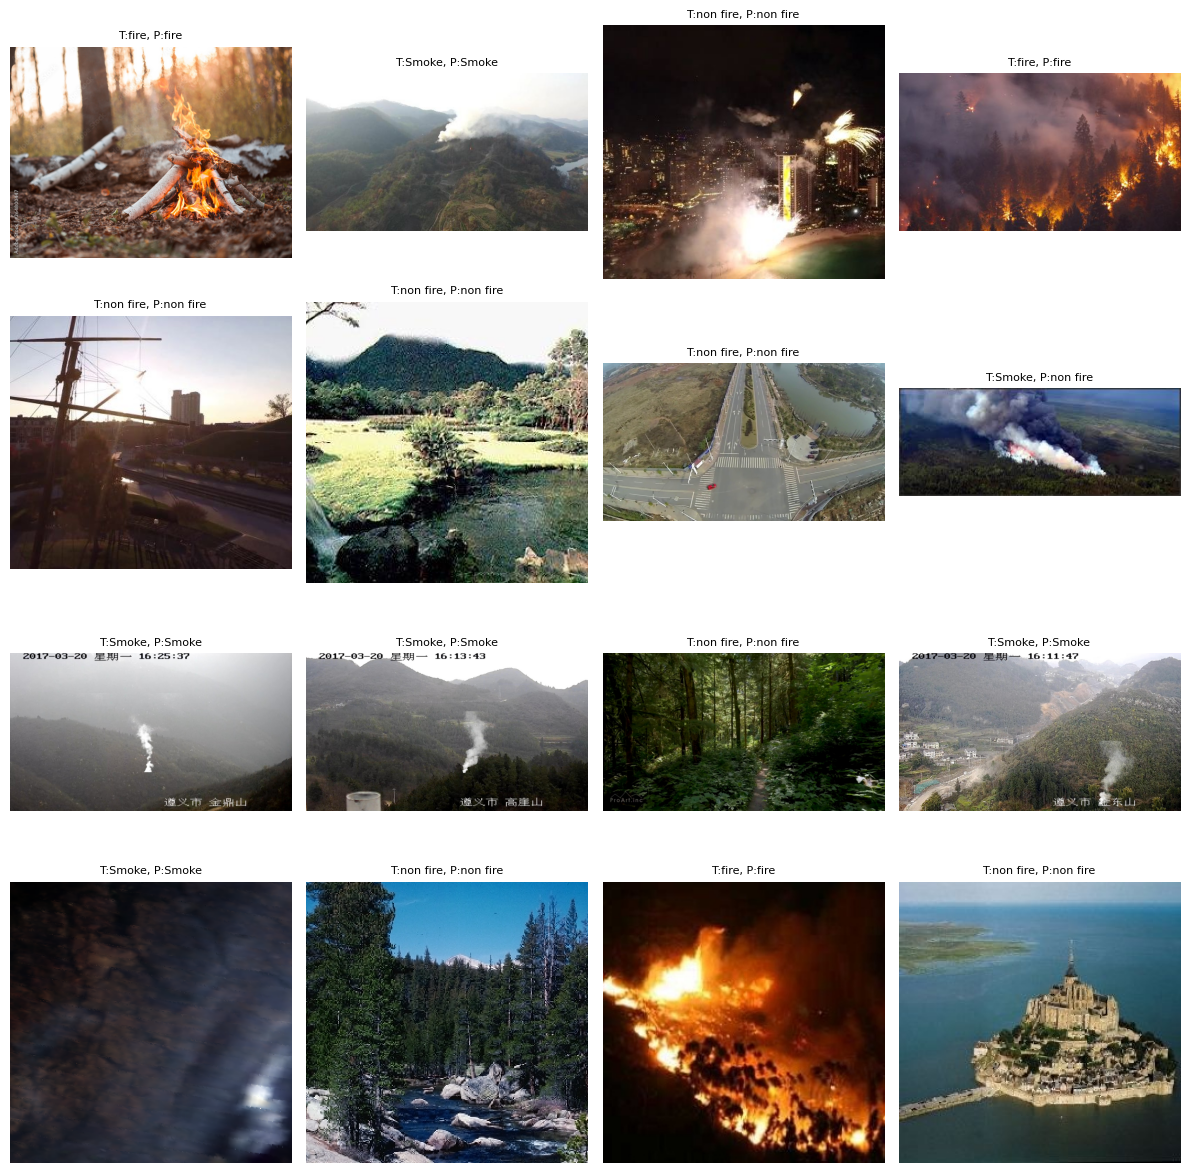

In [ ]:
from PIL import Image
#visualise predictions few of them to show side-by-side how well predictions match reality on sample test images.

import random
filepaths = test_data.filepaths
indices = random.sample(range(len(filepaths)), 16)

plt.figure(figsize=(12,12))
for i, idx in enumerate(indices):
    img = Image.open(filepaths[idx])
    true_label = class_labels[y_true[idx]]
    pred_label = class_labels[y_pred_classes[idx]]
    plt.subplot(4,4,i+1)
    plt.imshow(img)
    plt.title(f"T:{true_label}, P:{pred_label}", fontsize=8)
    plt.axis('off')
    print(f"Plot {i+1}: {filepaths[idx]} (T:{true_label}, P:{pred_label})")
plt.tight_layout()
plt.show()